# Clasificación de severidad de daños vehiculares para triage de siniestros
## CNN desde cero + comparación con Transfer Learning + Auditoría con Grad-CAM
Diplomado Data Analytics | Curso Deep Learning

| Equipo de Trabajo | |
| :--- | :--- |
| Cesar Augusto Romero Aranda |
| Esteban Tocto Cano |
| German Rodrigo Guerra Wiegman |
| Emmil Parras Salinas |
| Sara Katiuska Diaz Mendo | |
**Fundamento teórico:** Selvaraju et al. (2020), *Grad-CAM: Visual Explanations from Deep Networks via Gradient-Based Localization*, IJCV.

---

### Contextualización del problema de negocio

En el flujo actual de una aseguradora, un ajustador humano revisa fotos del vehículo siniestrado para
estimar la severidad del daño y aproximar el costo de reparación. Este proceso es lento y es el principal
cuello de botella en el tiempo de resolución de un siniestro (`claim cycle time`). Un clasificador automático
de severidad no reemplaza al ajustador, pero permite **triage**: enrutar los casos "minor" a aprobación
rápida/automática, y priorizar la revisión humana en los casos "moderate"/"severe" donde el costo de un
error es más alto.

**Por qué esto no es un problema categórico estándar:** las clases `minor < moderate < severe` tienen
un orden. Confundir `minor` con `severe` es un error mucho más costoso para el negocio que confundir
`minor` con `moderate`. Cross-Entropy estándar no distingue esto — lo vamos a medir explícitamente con
**Cohen's Kappa cuadrático**, que penaliza más los errores "lejanos" en la escala ordinal.

**Por qué Grad-CAM es indispensable aquí, no un accesorio:** un modelo con buen accuracy pero que
aprendió a inferir severidad a partir de correlaciones espurias (ej. el color del auto, el fondo de la foto,
la marca) es un riesgo legal y de negocio inaceptable en un sistema que afecta pagos de seguros. Grad-CAM
es nuestra herramienta de auditoría antes de considerar cualquier despliegue.

### Sobre los datos de este notebook
Se usa el **100% de las imágenes** del dataset de Kaggle (no se descarta ni submuestrea nada). Para
compensar que el dataset tiene solo unos pocos miles de imágenes -especialmente limitante para el CNN
entrenado desde cero, que no tiene el prior de ImageNet- se usa **Data Augmentation**: la técnica de
generar variaciones sintéticas de cada imagen de entrenamiento (rotaciones, flips, cambios de brillo/
color) para que el modelo vea más diversidad de la que el dataset original ofrece por sí solo. Se explica
en detalle en la Sección 3.1.


## 1. Setup y dependencias

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn kagglehub -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report, cohen_kappa_score)
from sklearn.model_selection import train_test_split
from collections import Counter
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ["minor", "moderate", "severe"]     # orden ordinal explícito -> índices 0,1,2
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

Device: cuda


## 2. Data

Dataset: **Car Damage Severity Dataset** (Kaggle, `prajwalbhamere/car-damage-severity-dataset`).
Carpetas `training/` y `validation/`, cada una con subcarpetas `minor/`, `moderate/`, `severe/`.

Se usa el **100% de las imágenes de ambas carpetas** (nada se descarta): las de `training/` van al pool
de entrenamiento, y las de `validation/` se reparten -mediante split estratificado- en validación y test,
para no evaluar el modelo final sobre datos que ya vio durante el early stopping.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("prajwalbhamere/car-damage-severity-dataset")
print("Dataset en:", path)
print(os.listdir(path))

100%|██████████| 13.8M/13.8M [00:00<00:00, 118MB/s] 

Extracting files...


Dataset en: /root/.cache/kagglehub/datasets/prajwalbhamere/car-damage-severity-dataset/versions/1
['data3a']


In [ ]:
# === CELDA DE DIAGNÓSTICO ===
for root, dirs, files in os.walk(path):
    depth = root.replace(path, "").count(os.sep)
    if depth <= 3:
        n_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print("  " * depth + f"[{depth}] {os.path.basename(root) or root} -- {n_files} imágenes, {len(dirs)} subcarpetas")

[0] 1 -- 0 imágenes, 1 subcarpetas
  [1] data3a -- 0 imágenes, 2 subcarpetas
    [2] validation -- 0 imágenes, 3 subcarpetas
      [3] 03-severe -- 91 imágenes, 0 subcarpetas
      [3] 01-minor -- 82 imágenes, 0 subcarpetas
      [3] 02-moderate -- 75 imágenes, 0 subcarpetas
    [2] training -- 0 imágenes, 3 subcarpetas
      [3] 03-severe -- 468 imágenes, 0 subcarpetas
      [3] 01-minor -- 452 imágenes, 0 subcarpetas
      [3] 02-moderate -- 463 imágenes, 0 subcarpetas


In [ ]:
# Estructura confirmada del dataset (verificada con os.walk):
# <path>/car-damage-severity-dataset/data3a/{training,validation}/{01-minor,02-moderate,03-severe}/*.jpg
TRAIN_DIR = os.path.join(path, "data3a", "training")
VAL_DIR   = os.path.join(path, "data3a", "validation")

# Si Kaggle llega a cambiar la estructura en el futuro, descomenta este diagnóstico para volver a verla:
# for root, dirs, files in os.walk(path):
#     depth = root.replace(path, "").count(os.sep)
#     if depth <= 3:
#         n_files = len([f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))])
#         print("  " * depth + f"[{depth}] {os.path.basename(root) or root} -- {n_files} imágenes, {len(dirs)} subcarpetas")

import re

def normalize_folder_name(name):
    """'01-minor', 'Minor', '02_moderate', 'SEVERE' -> 'minor', 'moderate', 'severe'"""
    name = name.lower().strip()
    name = re.sub(r"^[\d\-_.\s]+", "", name)   # quita prefijos numéricos tipo '01-', '02_'
    return name.strip()

def collect_samples(root_dir, class_to_idx=CLASS_TO_IDX):
    """Recorre root_dir/<clase>/*.jpg y arma una lista de (ruta_absoluta, indice_de_clase).
    Tolera que la carpeta se llame '01-minor', 'Minor', 'MINOR', etc. -- normaliza el nombre
    antes de compararlo contra CLASS_NAMES, y avisa en pantalla si alguna carpeta no matchea.
    """
    samples = []
    if not os.path.isdir(root_dir):
        print(f"[aviso] la carpeta no existe: {root_dir}")
        return samples

    subfolders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    print(f"Subcarpetas encontradas en {root_dir}: {subfolders}")

    for folder_name in subfolders:
        normalized = normalize_folder_name(folder_name)
        matched_class = None
        for cls in class_to_idx:
            if cls in normalized or normalized in cls:
                matched_class = cls
                break
        if matched_class is None:
            print(f"  [aviso] no pude mapear '{folder_name}' a ninguna clase de "
                  f"{list(class_to_idx.keys())} -- se ignora")
            continue

        idx = class_to_idx[matched_class]
        cls_dir = os.path.join(root_dir, folder_name)
        n_before = len(samples)
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                samples.append((os.path.join(cls_dir, fname), idx))
        print(f"  '{folder_name}' -> clase '{matched_class}': {len(samples) - n_before} imágenes")

    return samples

kaggle_train_samples = collect_samples(TRAIN_DIR)
kaggle_val_samples = collect_samples(VAL_DIR)

print(f"\ntraining/: {len(kaggle_train_samples)} imágenes")
print(f"validation/: {len(kaggle_val_samples)} imágenes")
for split_name, samples in [("training", kaggle_train_samples), ("validation", kaggle_val_samples)]:
    counts = Counter(lbl for _, lbl in samples)
    print(f"  {split_name} por clase:", {CLASS_NAMES[k]: v for k, v in counts.items()})

Subcarpetas encontradas en /root/.cache/kagglehub/datasets/prajwalbhamere/car-damage-severity-dataset/versions/1/data3a/training: ['03-severe', '01-minor', '02-moderate']
  '03-severe' -> clase 'severe': 468 imágenes
  '01-minor' -> clase 'minor': 452 imágenes
  '02-moderate' -> clase 'moderate': 463 imágenes
Subcarpetas encontradas en /root/.cache/kagglehub/datasets/prajwalbhamere/car-damage-severity-dataset/versions/1/data3a/validation: ['03-severe', '01-minor', '02-moderate']
  '03-severe' -> clase 'severe': 91 imágenes
  '01-minor' -> clase 'minor': 82 imágenes
  '02-moderate' -> clase 'moderate': 75 imágenes

training/: 1383 imágenes
validation/: 248 imágenes
  training por clase: {'severe': 468, 'minor': 452, 'moderate': 463}
  validation por clase: {'severe': 91, 'minor': 82, 'moderate': 75}


In [ ]:
# Split estratificado 50/50 de validation/ -> val / test (para no evaluar sobre datos usados en early stopping)
kaggle_val_labels = [lbl for _, lbl in kaggle_val_samples]
val_samples_final, test_samples_final = train_test_split(
    kaggle_val_samples, test_size=0.5, stratify=kaggle_val_labels, random_state=SEED
)
train_samples_final = kaggle_train_samples

print(f"TOTAL -> train: {len(train_samples_final)} | val: {len(val_samples_final)} | "
      f"test: {len(test_samples_final)}")
for name, s in [("train", train_samples_final), ("val", val_samples_final), ("test", test_samples_final)]:
    counts = Counter(lbl for _, lbl in s)
    print(f"  {name} por clase:", {CLASS_NAMES[k]: v for k, v in counts.items()})

TOTAL -> train: 1383 | val: 124 | test: 124
  train por clase: {'severe': 468, 'minor': 452, 'moderate': 463}
  val por clase: {'severe': 46, 'moderate': 37, 'minor': 41}
  test por clase: {'severe': 45, 'minor': 41, 'moderate': 38}


## 3. Pipeline de datos

**Dos pipelines de normalización distintos y por qué:**
- Para el **CNN desde cero**: normalización simple `(0.5, 0.5, 0.5)` — no hay razón para usar las
  estadísticas de ImageNet si no hay pesos preentrenados de por medio.
- Para el **ResNet18 con transfer learning**: normalización con medias/std de ImageNet — el backbone
  preentrenado espera esa distribución de entrada.

### 3.1 Data Augmentation — generar variaciones sintéticas de cada imagen

Esta es la técnica que buscabas: se llama **Data Augmentation**. La idea es aplicar transformaciones
aleatorias (pero realistas para el dominio) a cada imagen de entrenamiento, distinta en cada época, de
modo que el modelo nunca vea exactamente el mismo tensor dos veces — es una forma barata de "generar más
datos" sin necesidad de fotos nuevas, y es el estándar de la industria para reducir overfitting cuando
el dataset es chico.

**Por qué es especialmente importante para el CNN entrenado desde cero:** al no tener el prior de
ImageNet actuando como regularizador implícito (como sí lo tiene ResNet18 preentrenado), este modelo
depende mucho más de la diversidad artificial que le demos durante el entrenamiento para no memorizar
el dataset.

**Transformaciones aplicadas (solo en train, nunca en val/test):**

| Transformación | Rango | Por qué es razonable para fotos de autos dañados |
|---|---|---|
| Recorte aleatorio | crop de 224 sobre resize a 256 | Simula variación de encuadre/distancia de la foto |
| Flip horizontal | 50% de probabilidad | Un auto dañado del lado izquierdo es igual de válido reflejado |
| Rotación | ±15° | Simula que la foto no siempre está perfectamente nivelada |
| Brillo/Contraste/Saturación | ±25% / ±25% / ±15% | Simula distintas condiciones de luz al tomar la foto (interior, exterior, flash) |

**Nota importante:** no usamos flip vertical ni rotaciones grandes (90°, 180°) — un auto "de cabeza" no
es una variación realista, sería ruido, no augmentation útil.


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
SIMPLE_MEAN = [0.5, 0.5, 0.5]
SIMPLE_STD = [0.5, 0.5, 0.5]
IMG_SIZE = 224

def make_transforms(mean, std, train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(IMG_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

train_tf_scratch = make_transforms(SIMPLE_MEAN, SIMPLE_STD, train=True)
eval_tf_scratch  = make_transforms(SIMPLE_MEAN, SIMPLE_STD, train=False)
train_tf_resnet  = make_transforms(IMAGENET_MEAN, IMAGENET_STD, train=True)
eval_tf_resnet   = make_transforms(IMAGENET_MEAN, IMAGENET_STD, train=False)

In [ ]:
# Conteo real de imágenes (esto no cambia por el augmentation)
print(f"Imágenes de entrenamiento: {len(train_samples_final)}")
print(f"Imágenes de validación:    {len(val_samples_final)}")
print(f"Imágenes de test:          {len(test_samples_final)}")
print(f"TOTAL dataset:             {len(train_samples_final) + len(val_samples_final) + len(test_samples_final)}")

# "Vistas" generadas por Data Augmentation a lo largo del entrenamiento
# (variaciones efímeras -- no se guardan como archivos, se descartan cada época)
epocas_cnn = len(history_scratch["train_loss"])       # cuántas épocas corrió realmente el CNN
vistas_cnn = len(train_samples_final) * epocas_cnn

print(f"\nCNN desde cero corrió {epocas_cnn} épocas")
print(f"-> {len(train_samples_final)} imágenes x {epocas_cnn} épocas = {vistas_cnn:,} vistas distintas generadas por augmentation")

# ResNet18: si usaste fine-tuning por etapas, suma las 3 etapas
if "history_a" in dir() and "history_b" in dir():
    epocas_resnet = len(history_a["train_loss"]) + len(history_b["train_loss"]) + len(history_resnet["train_loss"])
else:
    epocas_resnet = len(history_resnet["train_loss"])

vistas_resnet = len(train_samples_final) * epocas_resnet
print(f"\nResNet18 corrió {epocas_resnet} épocas en total (todas las etapas)")
print(f"-> {len(train_samples_final)} imágenes x {epocas_resnet} épocas = {vistas_resnet:,} vistas distintas generadas por augmentation")

Imágenes de entrenamiento: 1383
Imágenes de validación:    124
Imágenes de test:          124
TOTAL dataset:             1631

CNN desde cero corrió 38 épocas
-> 1383 imágenes x 38 épocas = 52,554 vistas distintas generadas por augmentation

ResNet18 corrió 12 épocas en total (todas las etapas)
-> 1383 imágenes x 12 épocas = 16,596 vistas distintas generadas por augmentation


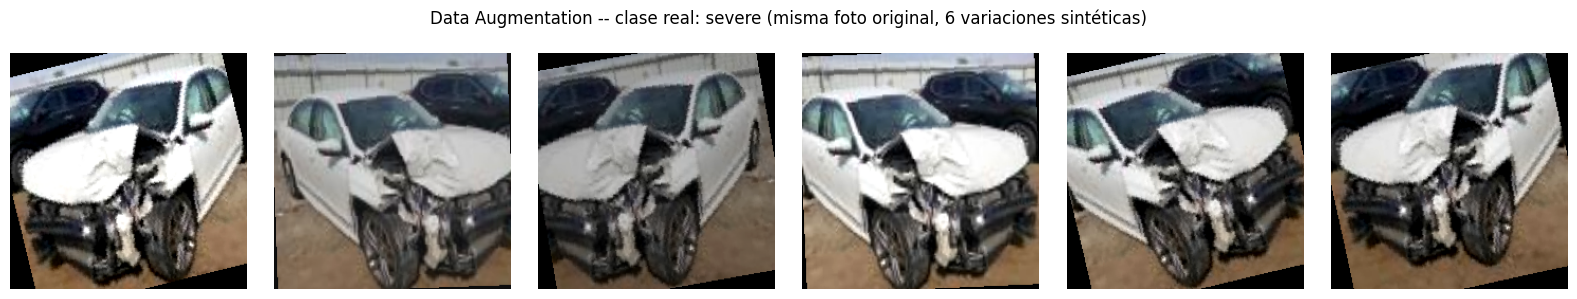

In [ ]:
# Visualización: una misma imagen, 6 versiones "sintéticas" distintas generadas por augmentation.
# Esto es literalmente lo que el modelo va a ver -- una versión distinta cada época, nunca la misma.
sample_path, sample_label = train_samples_final[0]
sample_img = Image.open(sample_path).convert("RGB")

# Transform solo de augmentation, sin normalizar (para poder visualizarlo directamente)
viz_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
])

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
fig.suptitle(f"Data Augmentation -- clase real: {CLASS_NAMES[sample_label]} "
             f"(misma foto original, 6 variaciones sintéticas)")
for ax in axes:
    augmented = viz_transform(sample_img)
    ax.imshow(augmented)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
class ListImageDataset(Dataset):
    """Dataset genérico a partir de una lista [(ruta, etiqueta), ...]."""
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


BATCH_SIZE = 32

train_ds_s = ListImageDataset(train_samples_final, train_tf_scratch)
val_ds_s   = ListImageDataset(val_samples_final, eval_tf_scratch)
test_ds_s  = ListImageDataset(test_samples_final, eval_tf_scratch)

train_ds_r = ListImageDataset(train_samples_final, train_tf_resnet)
val_ds_r   = ListImageDataset(val_samples_final, eval_tf_resnet)
test_ds_r  = ListImageDataset(test_samples_final, eval_tf_resnet)

train_loader_s = DataLoader(train_ds_s, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_s   = DataLoader(val_ds_s, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_s  = DataLoader(test_ds_s, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_loader_r = DataLoader(train_ds_r, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_r   = DataLoader(val_ds_r, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_r  = DataLoader(test_ds_r, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds_s)} | Val: {len(val_ds_s)} | Test: {len(test_ds_s)}")

Train: 1383 | Val: 124 | Test: 124


In [ ]:
# Class weights (compensa el desbalance de clases del dataset)
train_targets = [lbl for _, lbl in train_samples_final]
class_counts = Counter(train_targets)
total = sum(class_counts.values())
n_classes = len(CLASS_NAMES)

class_weights = torch.tensor(
    [total / (n_classes * class_counts.get(i, 1)) for i in range(n_classes)],
    dtype=torch.float32
).to(device)

print("Distribución de clases (train):", {CLASS_NAMES[k]: v for k, v in class_counts.items()})
print("Class weights:", class_weights.tolist())

Distribución de clases (train): {'severe': 468, 'minor': 452, 'moderate': 463}
Class weights: [1.019911527633667, 0.9956803321838379, 0.9850427508354187]


## 4. Arquitectura A — CNN desde cero

**Decisión de diseño deliberada:** en lugar de terminar con `Flatten() + Dense`, usamos
**Global Average Pooling (GAP)** justo antes de la capa final. Esto no es solo una elección de
regularización (GAP tiene cero parámetros vs. una Dense de miles) — es la arquitectura que el propio
paper de Grad-CAM identifica como **caso especial exacto de CAM** (Sec. 3.1, Ec. 3-11): cuando el mapa
de features pasa directo por GAP a una capa lineal, los pesos de esa capa lineal son *matemáticamente
equivalentes* a los pesos de importancia que Grad-CAM calcula vía gradientes.

**Justificación de hiperparámetros:**

| Elemento | Valor | Justificación |
|---|---|---|
| Bloques conv | 4 (32→64→128→256→512 canales) | Duplicar canales al reducir resolución espacial es el patrón estándar para preservar capacidad representacional |
| BatchNorm | después de cada conv | Sin pesos preentrenados, BN es crítico para estabilizar el entrenamiento desde una inicialización aleatoria |
| Dropout | 0.5 antes de la capa final | Regularización adicional a la que ya aporta Data Augmentation |
| GAP en vez de Flatten | — | Menos parámetros, menos overfitting, compatibilidad directa con CAM/Grad-CAM |


In [ ]:
class CarDamageCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),      # 224 -> 112
            conv_block(32, 64),     # 112 -> 56
            conv_block(64, 128),    # 56 -> 28
            conv_block(128, 256),   # 28 -> 14
            conv_block(256, 512),   # 14 -> 7    <- bloque nuevo, iguala la resolución de ResNet
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)   # <-- ojo: cambia de 256 a 512 aquí

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

model_scratch = CarDamageCNN(num_classes=3).to(device)

total_params = sum(p.numel() for p in model_scratch.parameters())
print(f"Parámetros totales (CNN desde cero): {total_params:,}")

Parámetros totales (CNN desde cero): 1,572,099


## 5. Arquitectura B — ResNet18 con Transfer Learning (baseline de comparación)

Mismo criterio de congelamiento que en el proyecto anterior: `conv1` a `layer2` congeladas (features
genéricas), `layer3`/`layer4` descongeladas (adaptación semántica al dominio), `fc` reemplazada.


In [ ]:
edef set_trainable(model, layer_prefixes):
    """Congela todo excepto los parámetros cuyo nombre empiece con alguno de layer_prefixes."""
    for name, param in model.named_parameters():
        param.requires_grad = any(name.startswith(p) for p in layer_prefixes)

def build_resnet_model_staged():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False          # todo congelado al inicio
    m.fc = nn.Linear(m.fc.in_features, 3)  # capa nueva, siempre entrenable
    for p in m.fc.parameters():
        p.requires_grad = True
    return m.to(device)

model_resnet = build_resnet_model_staged()
trainable = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_resnet.parameters())
print(f"Etapa inicial -- Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Etapa inicial -- Parámetros entrenables: 1,539 / 11,178,051 (0.0%)


## 6. Entrenamiento (función genérica para ambos modelos)

**Diferencia clave de hiperparámetros entre A y B:**
- CNN desde cero: LR más alto (1e-3), más épocas (patience mayor) — parte de pesos aleatorios, necesita
  más señal de gradiente y más tiempo para converger.
- ResNet18: LR bajo con esquema diferencial — los pesos ya están cerca de un buen óptimo, solo se
  ajustan finamente.


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, preds_all, labels_all = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * x.size(0)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(labels_all, preds_all)
    return avg_loss, acc


def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler,
                 epochs, patience, tag):
    best_val_loss, patience_counter = float("inf"), 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    ckpt_path = f"best_{tag}.pt"

    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["train_loss"].append(tr_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc); history["val_acc"].append(val_acc)

        print(f"[{tag}] Epoch {epoch+1}/{epochs} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={val_loss:.4f} acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[{tag}] Early stopping en epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(ckpt_path))
    return history

In [ ]:
# --- Entrenamiento CNN desde cero ---
criterion_s = nn.CrossEntropyLoss()   # sin weight=class_weights -- ya usas el sampler
optimizer_s = torch.optim.AdamW(model_scratch.parameters(), lr=5e-4, weight_decay=1e-4)  # antes: 1e-3
scheduler_s = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_s, mode="min", factor=0.5, patience=1)  # antes: patience=2

history_scratch = train_model(
    model_scratch, train_loader_s, val_loader_s, optimizer_s, criterion_s, scheduler_s,
    epochs=40, patience=8, tag="scratch"   # antes: patience=6 -- le damos más margen ya que el LR es más bajo
)

[scratch] Epoch 1/40 | train_loss=1.0965 acc=0.4534 | val_loss=1.1923 acc=0.3468
[scratch] Epoch 2/40 | train_loss=1.0183 acc=0.4642 | val_loss=0.8610 acc=0.5887
[scratch] Epoch 3/40 | train_loss=0.9815 acc=0.5221 | val_loss=0.8548 acc=0.5806
[scratch] Epoch 4/40 | train_loss=0.9764 acc=0.5206 | val_loss=0.8313 acc=0.6210
[scratch] Epoch 5/40 | train_loss=0.9657 acc=0.5177 | val_loss=0.8684 acc=0.5968
[scratch] Epoch 6/40 | train_loss=0.9675 acc=0.5155 | val_loss=0.7558 acc=0.7016
[scratch] Epoch 7/40 | train_loss=0.9590 acc=0.5380 | val_loss=0.8075 acc=0.6452
[scratch] Epoch 8/40 | train_loss=0.9359 acc=0.5553 | val_loss=0.7988 acc=0.6532
[scratch] Epoch 9/40 | train_loss=0.9014 acc=0.5698 | val_loss=0.7585 acc=0.6774
[scratch] Epoch 10/40 | train_loss=0.9068 acc=0.5785 | val_loss=0.7757 acc=0.6774
[scratch] Epoch 11/40 | train_loss=0.8923 acc=0.5647 | val_loss=0.7955 acc=0.6452
[scratch] Epoch 12/40 | train_loss=0.8803 acc=0.5777 | val_loss=0.7851 acc=0.6774
[scratch] Epoch 13/40 | t

In [ ]:
# --- Entrenamiento ResNet18 por ETAPAS (fine-tuning gradual) ---
# Sin weight=class_weights aquí: el WeightedRandomSampler ya balancea las clases a nivel de batch,
# aplicar los dos mecanismos a la vez sobre-corregiría el desbalance.
criterion_r = nn.CrossEntropyLoss()

# --- Etapa A: solo entrena la capa fc (todo lo demás sigue congelado) ---
optimizer_a = torch.optim.AdamW(model_resnet.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode="min", factor=0.5, patience=1)
print("=== Etapa A: solo fc ===")
history_a = train_model(model_resnet, train_loader_r, val_loader_r, optimizer_a, criterion_r, scheduler_a,
                         epochs=4, patience=2, tag="resnet_stageA")

# --- Etapa B: descongela layer4 ---
set_trainable(model_resnet, ["layer4", "fc"])
optimizer_b = torch.optim.AdamW([
    {"params": model_resnet.layer4.parameters(), "lr": 1e-4},
    {"params": model_resnet.fc.parameters(), "lr": 5e-4},
], weight_decay=1e-4)
scheduler_b = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b, mode="min", factor=0.5, patience=1)
print("\\n=== Etapa B: fc + layer4 ===")
history_b = train_model(model_resnet, train_loader_r, val_loader_r, optimizer_b, criterion_r, scheduler_b,
                         epochs=6, patience=2, tag="resnet_stageB")

# --- Etapa C: descongela layer3 también (arquitectura final, igual que antes) ---
set_trainable(model_resnet, ["layer3", "layer4", "fc"])
optimizer_c = torch.optim.AdamW([
    {"params": model_resnet.layer3.parameters(), "lr": 1e-4},
    {"params": model_resnet.layer4.parameters(), "lr": 1e-4},
    {"params": model_resnet.fc.parameters(), "lr": 1e-3},
], weight_decay=1e-4)
scheduler_c = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_c, mode="min", factor=0.5, patience=1)
print("\\n=== Etapa C: fc + layer4 + layer3 ===")
history_resnet = train_model(model_resnet, train_loader_r, val_loader_r, optimizer_c, criterion_r, scheduler_c,
                              epochs=15, patience=3, tag="resnet_stageC")

=== Etapa A: solo fc ===
[resnet_stageA] Epoch 1/4 | train_loss=1.0564 acc=0.4497 | val_loss=0.8668 acc=0.6129
[resnet_stageA] Epoch 2/4 | train_loss=0.9514 acc=0.5343 | val_loss=0.8091 acc=0.6613
[resnet_stageA] Epoch 3/4 | train_loss=0.8865 acc=0.5719 | val_loss=0.7707 acc=0.6694
[resnet_stageA] Epoch 4/4 | train_loss=0.8521 acc=0.6001 | val_loss=0.7864 acc=0.6613
\n=== Etapa B: fc + layer4 ===
[resnet_stageB] Epoch 1/6 | train_loss=0.8137 acc=0.6103 | val_loss=0.7075 acc=0.6532
[resnet_stageB] Epoch 2/6 | train_loss=0.6573 acc=0.7223 | val_loss=0.6983 acc=0.6210
[resnet_stageB] Epoch 3/6 | train_loss=0.5588 acc=0.7693 | val_loss=0.7279 acc=0.6694
[resnet_stageB] Epoch 4/6 | train_loss=0.4930 acc=0.7874 | val_loss=0.7202 acc=0.6048
[resnet_stageB] Early stopping en epoch 4
\n=== Etapa C: fc + layer4 + layer3 ===
[resnet_stageC] Epoch 1/15 | train_loss=0.6371 acc=0.7231 | val_loss=0.6905 acc=0.6371
[resnet_stageC] Epoch 2/15 | train_loss=0.4454 acc=0.8228 | val_loss=1.0439 acc=0.5806


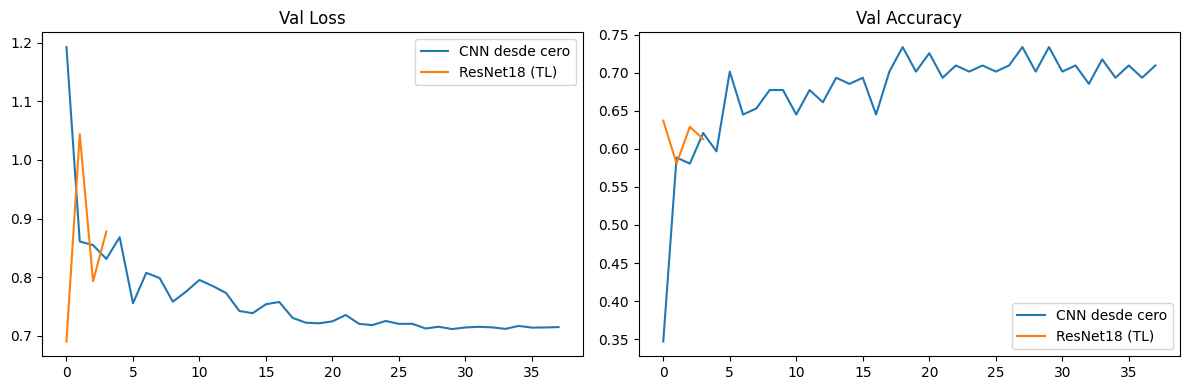

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_scratch["val_loss"], label="CNN desde cero")
axes[0].plot(history_resnet["val_loss"], label="ResNet18 (TL)")
axes[0].set_title("Val Loss"); axes[0].legend()
axes[1].plot(history_scratch["val_acc"], label="CNN desde cero")
axes[1].plot(history_resnet["val_acc"], label="ResNet18 (TL)")
axes[1].set_title("Val Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Evaluación comparativa en test set

**Por qué Cohen's Kappa cuadrático además de accuracy/F1:**
Penaliza más los errores "lejanos" en la escala ordinal (confundir minor↔severe pesa más que
minor↔moderate). Un modelo con el mismo accuracy pero mayor Kappa cuadrático está cometiendo errores
"más baratos" para el negocio — esta es la métrica que deberías reportar como criterio principal de
decisión, no accuracy.



=== CNN desde cero ===
              precision    recall  f1-score   support

       minor       0.76      0.63      0.69        41
    moderate       0.34      0.34      0.34        38
      severe       0.63      0.73      0.68        45

    accuracy                           0.58       124
   macro avg       0.58      0.57      0.57       124
weighted avg       0.59      0.58      0.58       124

Cohen's Kappa (cuadrático): 0.6605

=== ResNet18 (TL) ===
              precision    recall  f1-score   support

       minor       0.65      0.83      0.73        41
    moderate       0.48      0.39      0.43        38
      severe       0.80      0.73      0.77        45

    accuracy                           0.66       124
   macro avg       0.65      0.65      0.64       124
weighted avg       0.66      0.66      0.65       124

Cohen's Kappa (cuadrático): 0.7162


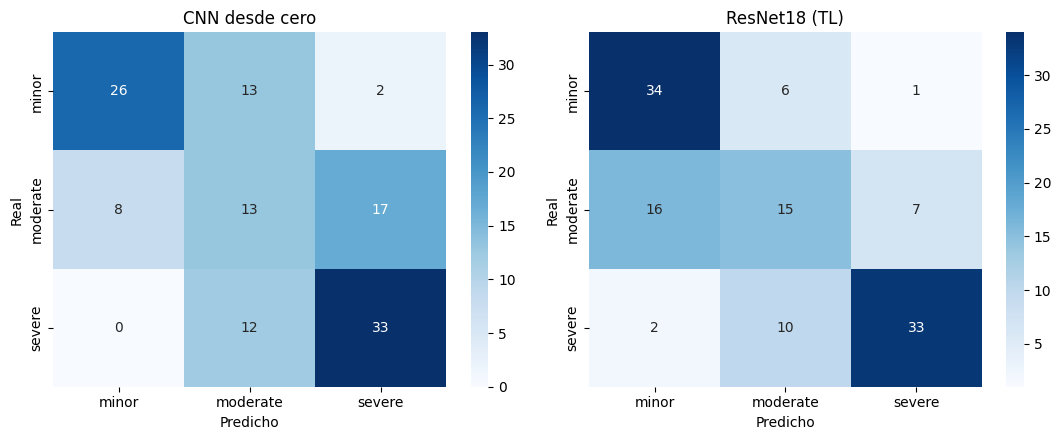

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(y.numpy())
    return np.array(labels_all), np.array(preds_all)

y_true_s, y_pred_s = evaluate_model(model_scratch, test_loader_s)
y_true_r, y_pred_r = evaluate_model(model_resnet, test_loader_r)

for name, y_true, y_pred in [("CNN desde cero", y_true_s, y_pred_s), ("ResNet18 (TL)", y_true_r, y_pred_r)]:
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    print(f"Cohen's Kappa (cuadrático): {kappa:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name, y_true, y_pred in [
    (axes[0], "CNN desde cero", y_true_s, y_pred_s),
    (axes[1], "ResNet18 (TL)", y_true_r, y_pred_r),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(name); ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

## 8. Grad-CAM — implementación desde cero (reutilizable para ambos modelos)

Misma implementación matemática de siempre (Selvaraju et al. 2020, Ec. 1-2), pero ahora la vamos a
usar sobre **dos arquitecturas distintas** apuntando cada una a su propia última capa convolucional.


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        self.model.zero_grad()
        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        alpha = self.gradients.mean(dim=(2, 3), keepdim=True)          # Ec. 1: GAP de gradientes
        weighted = (alpha * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(weighted)                                        # Ec. 2: combinación lineal + ReLU

        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, F.softmax(logits, dim=1).detach().cpu().numpy()[0]

gradcam_scratch = GradCAM(model_scratch, target_layer=model_scratch.features[-1][0])
gradcam_resnet  = GradCAM(model_resnet, target_layer=model_resnet.layer4[-1])

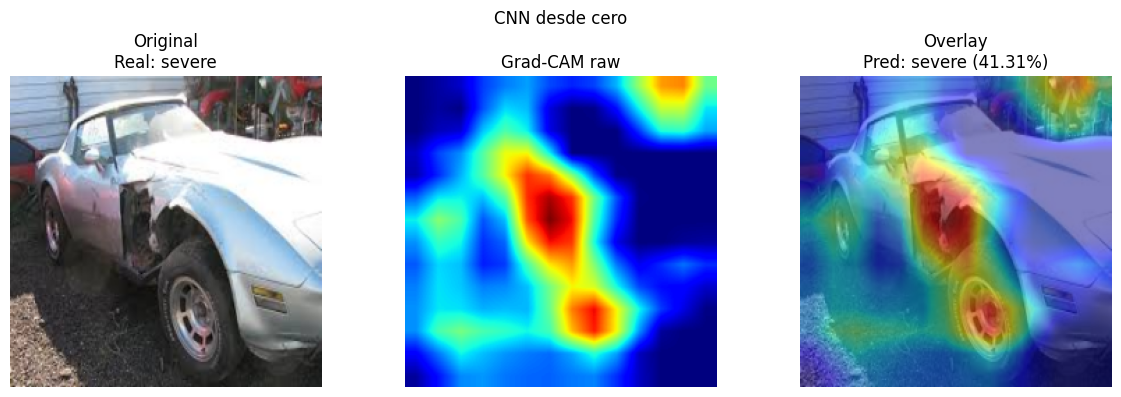

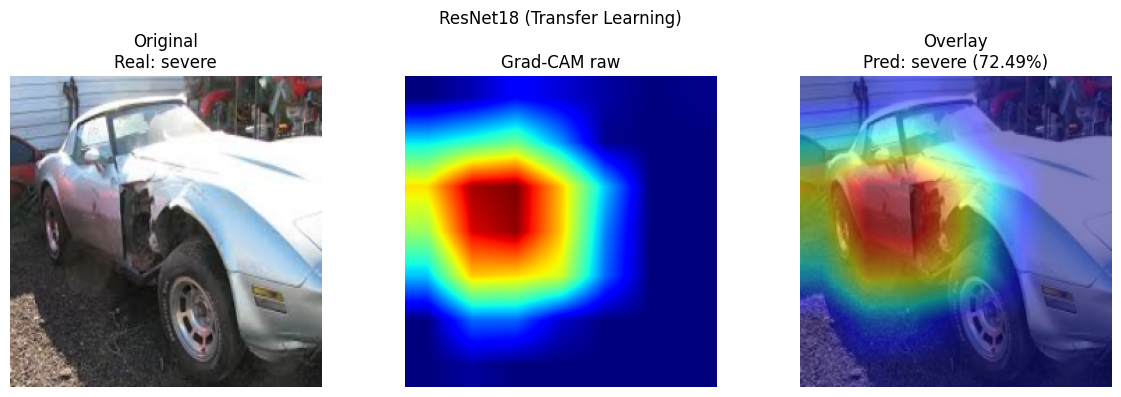

In [ ]:
def denormalize(tensor, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = tensor.cpu() * std_t + mean_t
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

def plot_gradcam(model, dataset, idx, grad_cam, mean, std, class_names=CLASS_NAMES, model_name=""):
    img_tensor, true_label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    cam, pred_class, probs = grad_cam.generate(input_tensor)
    img = denormalize(img_tensor, mean, std)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(model_name)
    axes[0].imshow(img); axes[0].set_title(f"Original\nReal: {class_names[true_label]}")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM raw")
    axes[2].imshow(img); axes[2].imshow(cam, cmap="jet", alpha=0.5)
    axes[2].set_title(f"Overlay\nPred: {class_names[pred_class]} ({probs[pred_class]:.2%})")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

test_ds_scratch = test_loader_s.dataset
test_ds_resnet = test_loader_r.dataset
correct_idx = np.where(y_true_s == y_pred_s)[0][0]

plot_gradcam(model_scratch, test_ds_scratch, correct_idx, gradcam_scratch,
             SIMPLE_MEAN, SIMPLE_STD, model_name="CNN desde cero")
plot_gradcam(model_resnet, test_ds_resnet, correct_idx, gradcam_resnet,
             IMAGENET_MEAN, IMAGENET_STD, model_name="ResNet18 (Transfer Learning)")

## 9. Auditoría de negocio: ¿el modelo mira el daño real?

**Checklist de auditoría a documentar en el informe (con evidencia visual de Grad-CAM):**

1. **¿El heatmap se concentra en la zona de daño (abolladura, rayón, cristal roto)?**
2. **¿El heatmap se concentra en el fondo, el logo de la marca, o la placa?** → correlación espuria.
3. **En los casos mal clasificados, ¿el error es "razonable"?**
4. **Comparación entre modelos:** ¿cuál tiene un Grad-CAM más nítido y localizado?


CNN desde cero -- casos mal clasificados: 52 / 124


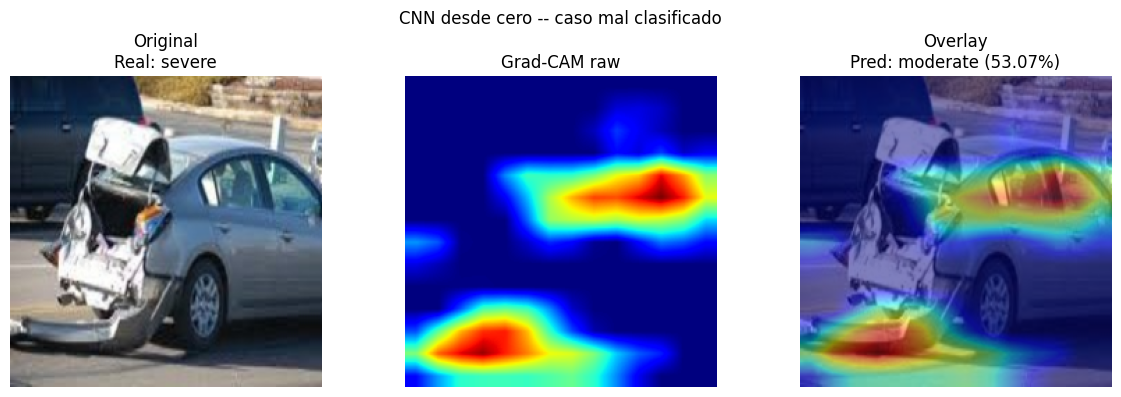

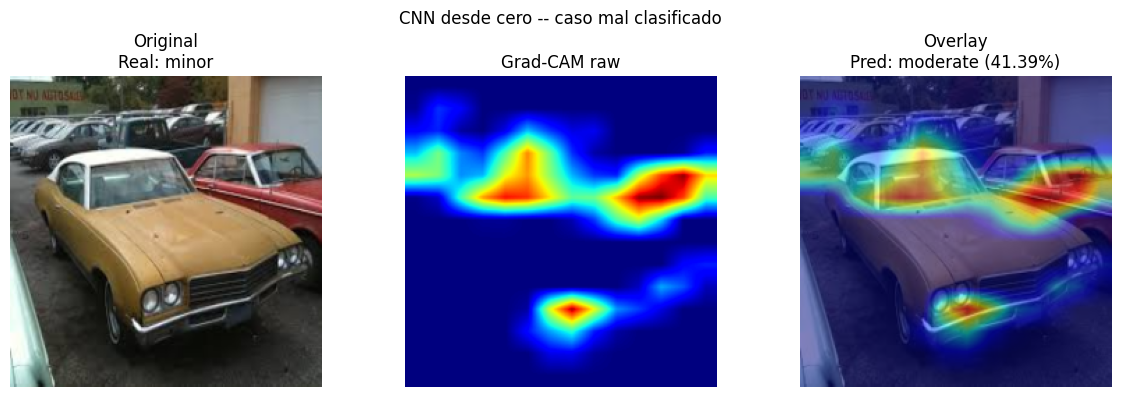

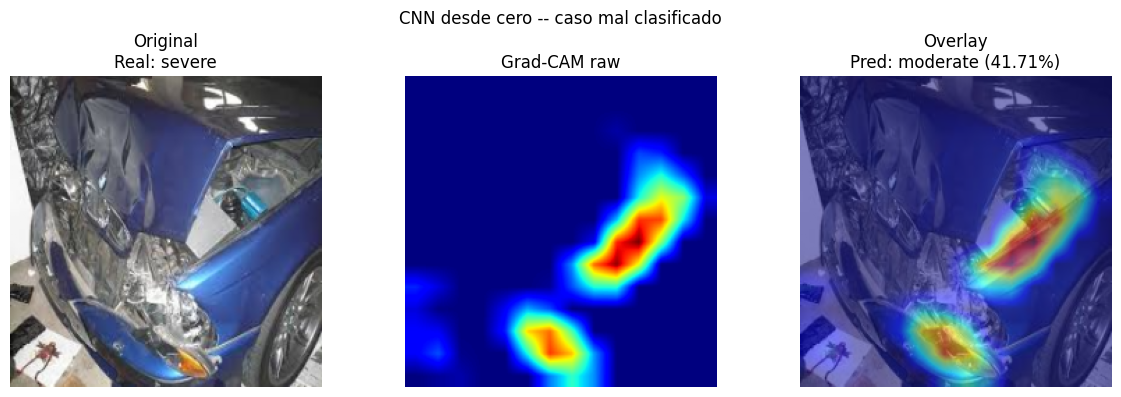

In [ ]:
misclassified_idx = np.where(y_true_s != y_pred_s)[0]
print(f"CNN desde cero -- casos mal clasificados: {len(misclassified_idx)} / {len(y_true_s)}")

for idx in misclassified_idx[:3]:
    plot_gradcam(model_scratch, test_ds_scratch, idx, gradcam_scratch,
                 SIMPLE_MEAN, SIMPLE_STD, model_name="CNN desde cero -- caso mal clasificado")

## 10. Conclusiones y limitaciones

- **Comparación cuantitativa:** reportar accuracy, F1 por clase y Kappa cuadrático de ambos modelos.
- **Auditoría cualitativa:** ¿alguno de los dos modelos es "desplegable" en su estado actual?
- **Efecto del Data Augmentation:** Correr un experimento adicional entrenando el CNN
  desde cero SIN augmentation (transforms.Compose solo con Resize+ToTensor+Normalize) y compara el
  val_loss -- deberías ver overfitting más temprano y peor generalización. Ese contraste es evidencia
  concreta y fácil de mostrar de que la técnica realmente está cumpliendo su función.
- **Limitación de dataset:** el dataset contiene fotos ya curadas y encuadradas hacia el daño; una foto
  real de un cliente (fondo, ángulos, mala luz) es más difícil que cualquier variación sintética que
  genere el augmentation -- el desempeño reportado aquí es un techo optimista, no una estimación de
  desempeño en producción.
- **Extensión futura:** tratar el problema como regresión ordinal (ej. CORAL loss).


## 11. Probar el modelo con una imagen puntual (Google Colab)

Esta sección es independiente del resto: solo necesitas haber corrido las Secciones 4-8 antes de llegar
aquí (definición, entrenamiento y Grad-CAM de los modelos).

Tienes **dos formas** de elegir la imagen a probar, controladas por la variable `IMAGE_SOURCE`:

- `IMAGE_SOURCE = "existente"`: eliges una imagen que ya está en el test set, indicando su índice.
- `IMAGE_SOURCE = "subir"`: subes una foto nueva en el momento, que no pasó por entrenamiento ni evaluación.


In [ ]:
# --- CONFIGURACIÓN: AJUSTA AQUÍ ---
IMAGE_SOURCE = "subir"     # "existente" (usar una del test set) o "subir" (subir una foto nueva)
EXISTING_IMAGE_INDEX = 0       # <-- CAMBIA este número si IMAGE_SOURCE = "existente" (ver rango abajo)
MODEL_TO_USE = "resnet"        # "resnet" o "scratch" -- elige qué modelo entrenado quieres probar
# ------------------------------------

print(f"El test set tiene {len(test_samples_final)} imágenes disponibles "
      f"(índices válidos: 0 a {len(test_samples_final) - 1}).")

if IMAGE_SOURCE == "existente":
    image_path, true_label = test_samples_final[EXISTING_IMAGE_INDEX]
    print(f"Imagen elegida: {image_path}  (clase real: {CLASS_NAMES[true_label]})")
    image_paths_to_test = [image_path]
elif IMAGE_SOURCE == "subir":
    from google.colab import files
    print("Selecciona una o más imágenes desde tu computadora:")
    uploaded = files.upload()
    image_paths_to_test = list(uploaded.keys())
else:
    raise ValueError('IMAGE_SOURCE debe ser "existente" o "subir"')

El test set tiene 124 imágenes disponibles (índices válidos: 0 a 123).
Selecciona una o más imágenes desde tu computadora:


Saving s-l1600-24-_webp.rf.568392715f63c0b64a929a15327dbec8.jpg to s-l1600-24-_webp.rf.568392715f63c0b64a929a15327dbec8.jpg
Saving s-l1600-55-_webp.rf.0e92cc3ed62949486eb59250970a533f.jpg to s-l1600-55-_webp.rf.0e92cc3ed62949486eb59250970a533f.jpg
Saving s-l1600-2025-03-07T192156_512_webp.rf.7478f0fe2020515554bb27fb948868c8.jpg to s-l1600-2025-03-07T192156_512_webp.rf.7478f0fe2020515554bb27fb948868c8.jpg


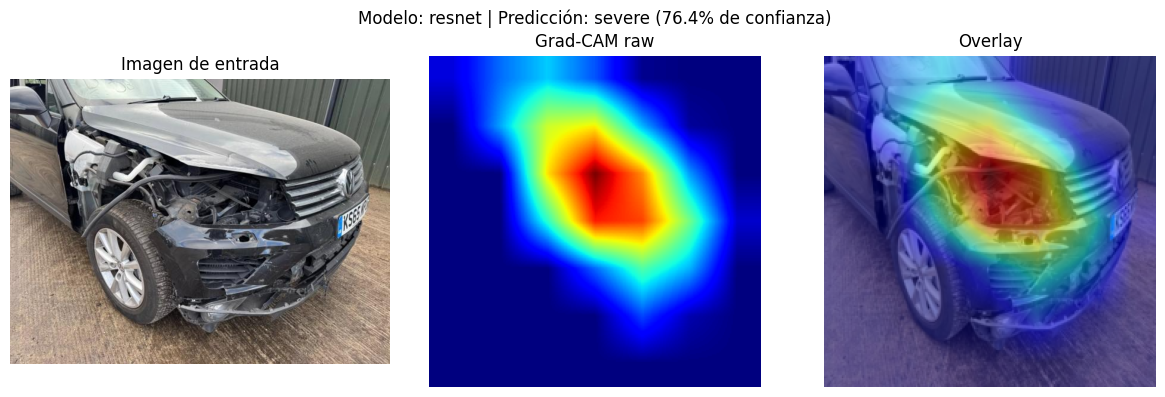

Probabilidades por clase: minor=2.2%, moderate=21.4%, severe=76.4%


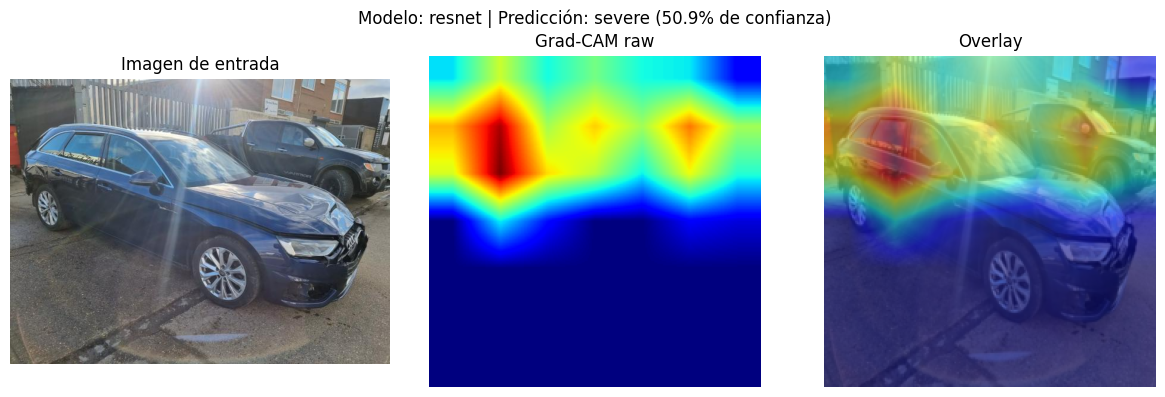

Probabilidades por clase: minor=25.4%, moderate=23.7%, severe=50.9%


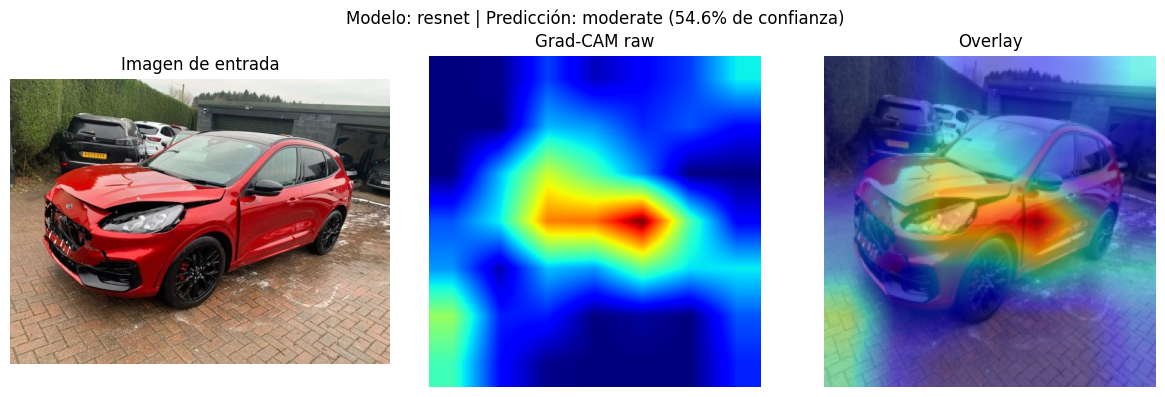

Probabilidades por clase: minor=15.6%, moderate=54.6%, severe=29.9%


In [ ]:
def predict_and_explain(image_path, model_name="resnet"):
    """Carga una imagen, la clasifica y genera su Grad-CAM."""
    pil_img = Image.open(image_path).convert("RGB")

    if model_name == "resnet":
        model, grad_cam, tf, mean, std = model_resnet, gradcam_resnet, eval_tf_resnet, IMAGENET_MEAN, IMAGENET_STD
    else:
        model, grad_cam, tf, mean, std = model_scratch, gradcam_scratch, eval_tf_scratch, SIMPLE_MEAN, SIMPLE_STD

    input_tensor = tf(pil_img).unsqueeze(0).to(device)
    cam, pred_class, probs = grad_cam.generate(input_tensor)
    img_denorm = denormalize(input_tensor.squeeze(0), mean, std)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Modelo: {model_name} | Predicción: {CLASS_NAMES[pred_class]} "
                 f"({probs[pred_class]:.1%} de confianza)")
    axes[0].imshow(pil_img); axes[0].set_title("Imagen de entrada")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM raw")
    axes[2].imshow(img_denorm); axes[2].imshow(cam, cmap="jet", alpha=0.5); axes[2].set_title("Overlay")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

    print(f"Probabilidades por clase: "
          + ", ".join(f"{CLASS_NAMES[i]}={probs[i]:.1%}" for i in range(len(CLASS_NAMES))))
    return pred_class, probs


for p_img in image_paths_to_test:
    predict_and_explain(p_img, model_name=MODEL_TO_USE)

In [ ]:
# --- CONFIGURACIÓN: AJUSTA AQUÍ ---
IMAGE_SOURCE = "subir"     # "existente" (usar una del test set) o "subir" (subir una foto nueva)
EXISTING_IMAGE_INDEX = 0       # <-- CAMBIA este número si IMAGE_SOURCE = "existente" (ver rango abajo)
MODEL_TO_USE = "scratch"        # "resnet" o "scratch" -- elige qué modelo entrenado quieres probar
# ------------------------------------

print(f"El test set tiene {len(test_samples_final)} imágenes disponibles "
      f"(índices válidos: 0 a {len(test_samples_final) - 1}).")

if IMAGE_SOURCE == "existente":
    image_path, true_label = test_samples_final[EXISTING_IMAGE_INDEX]
    print(f"Imagen elegida: {image_path}  (clase real: {CLASS_NAMES[true_label]})")
    image_paths_to_test = [image_path]
elif IMAGE_SOURCE == "subir":
    from google.colab import files
    print("Selecciona una o más imágenes desde tu computadora:")
    uploaded = files.upload()
    image_paths_to_test = list(uploaded.keys())
else:
    raise ValueError('IMAGE_SOURCE debe ser "existente" o "subir"')

El test set tiene 124 imágenes disponibles (índices válidos: 0 a 123).
Selecciona una o más imágenes desde tu computadora:


Saving s-l1600-11-_webp.rf.43066bba4ee5faf2d0ff53a927a6942e.jpg to s-l1600-11-_webp.rf.43066bba4ee5faf2d0ff53a927a6942e.jpg
Saving s-l1600-50-_webp.rf.e72c107865933199e37f5d68a61ecf17.jpg to s-l1600-50-_webp.rf.e72c107865933199e37f5d68a61ecf17.jpg
Saving s-l1600-79-_webp.rf.6cd83edb3a95122bb4c211814612b1f1.jpg to s-l1600-79-_webp.rf.6cd83edb3a95122bb4c211814612b1f1.jpg


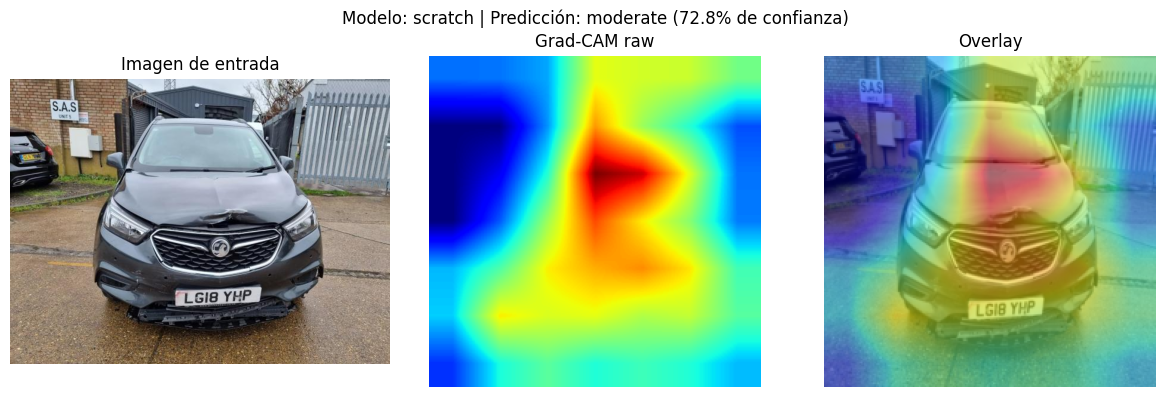

Probabilidades por clase: minor=13.5%, moderate=72.8%, severe=13.7%


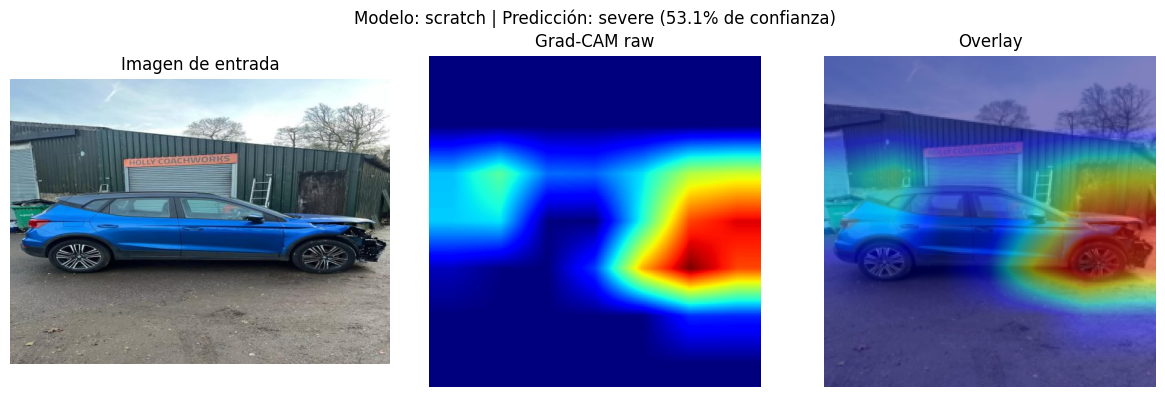

Probabilidades por clase: minor=17.3%, moderate=29.6%, severe=53.1%


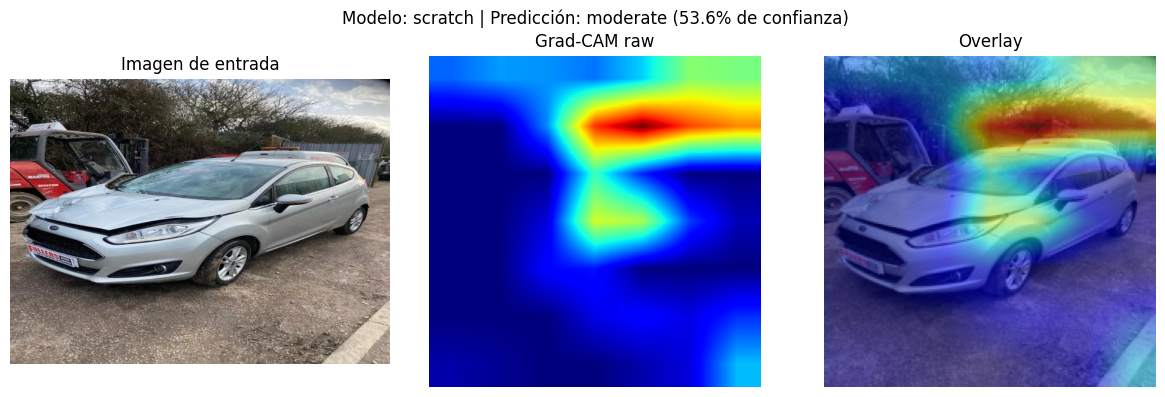

Probabilidades por clase: minor=25.6%, moderate=53.6%, severe=20.7%


In [ ]:
def predict_and_explain(image_path, model_name="resnet"):
    """Carga una imagen, la clasifica y genera su Grad-CAM."""
    pil_img = Image.open(image_path).convert("RGB")

    if model_name == "scratch":
        model, grad_cam, tf, mean, std = model_resnet, gradcam_resnet, eval_tf_resnet, IMAGENET_MEAN, IMAGENET_STD
    else:
        model, grad_cam, tf, mean, std = model_scratch, gradcam_scratch, eval_tf_scratch, SIMPLE_MEAN, SIMPLE_STD

    input_tensor = tf(pil_img).unsqueeze(0).to(device)
    cam, pred_class, probs = grad_cam.generate(input_tensor)
    img_denorm = denormalize(input_tensor.squeeze(0), mean, std)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"Modelo: {model_name} | Predicción: {CLASS_NAMES[pred_class]} "
                 f"({probs[pred_class]:.1%} de confianza)")
    axes[0].imshow(pil_img); axes[0].set_title("Imagen de entrada")
    axes[1].imshow(cam, cmap="jet"); axes[1].set_title("Grad-CAM raw")
    axes[2].imshow(img_denorm); axes[2].imshow(cam, cmap="jet", alpha=0.5); axes[2].set_title("Overlay")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

    print(f"Probabilidades por clase: "
          + ", ".join(f"{CLASS_NAMES[i]}={probs[i]:.1%}" for i in range(len(CLASS_NAMES))))
    return pred_class, probs


for p_img in image_paths_to_test:
    predict_and_explain(p_img, model_name=MODEL_TO_USE)